In [1]:
# OPENING IMPORTS

import numpy as np
from matplotlib import pyplot as plt
import xarray as xr

import zipfile as zp          # used for unzipping ppi files
from pathlib import Path      # used to play with pathnames to save 
from datetime import datetime # used to manipulate time :)

import wradlib as wr          # used for having fun with radar data

from PIL import Image         # used for creating gif loops
import os                     # used for retrieving file names

import h5py                   # used for reading .h5 files (Radar Level 1 data)
import h5netcdf               # used for converting .h5 files to NetCDF

# TAKEN FROM "Part4IntroductionToGridding"
import cartopy.crs as ccrs
import pyart
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

# # SPECIAL METHOD TO IMPORT LEROI RADAR GRIDDING PACKAGE AND CUSTOM FUNCTIONS FROM LOCAL DIRECTORY
import sys
sys.path.append('/home/563/sg3241/Notebooks/CustomFunctions')
from CustomFunctions1 import *
# from leroi.leroi import *


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



working on reading the file for 12:55:00


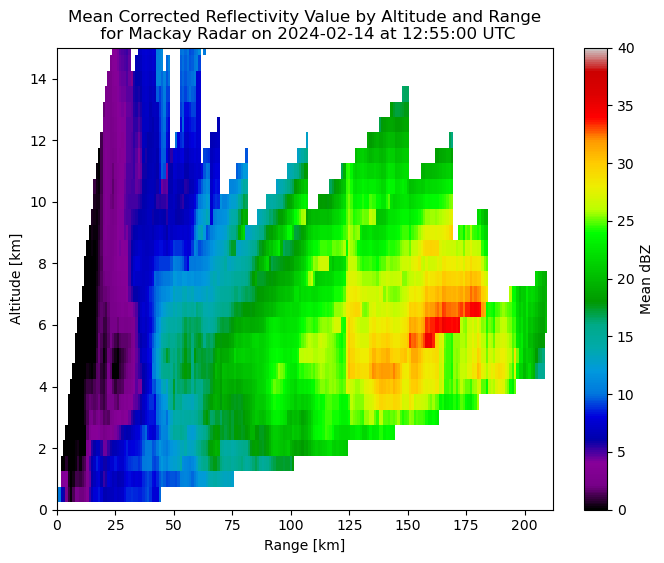

In [14]:
# Z by RANGE "FAKE CFAD"
# ADDED 2026-06-10T18:56UTC+10:00

# what does the radar data use for the "fill value"?
FillValue = -32

RangeInterval = 1 # [km] increments of range in the plot

# CHOOSE YOUR RADAR
RadarIDno = '22'  # 22 is Mackay, 106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marabong (near Bris)

# name the radar site
if (RadarIDno == '22'):
    RadarSiteName = 'Mackay'
elif (RadarIDno == '106'):
    RadarSiteName = 'Townsville'
elif (RadarIDno == '66'):
    RadarSiteName = 'Mt Staplyton'
elif (RadarIDno == '50'):
    RadarSiteName = 'Marabong'
else:
    RadarSiteName = 'Site ' + RadarIDno


# CHOOSE YOUR DAY
# the day in consideration (YYYYMMDD) and time (hhmmss)       ALL IN UTC !!!
RadarYear  = 2024
RadarMonth = 2
RadarDay   = 14

# CHOOSE YOUR HEIGHTS OF CONSIDERATION
MinHeight = 0 # [km] minimum height in the CFAD
MaxHeight = 15 # [km] maximum height in the CFAD

# LOOP OVER ALL SETS OF 5 MIN in the day
for houri in range(12,13):
    for mini in range(55,60,5):

        # add leading zeros for strings
        YYYY = str(RadarYear).zfill(4)
        MM = str(RadarMonth).zfill(2)
        DD = str(RadarDay).zfill(2)
        
        # write out the data in one string
        RadarFileDate  = YYYY + MM + DD 
        
        RadarFileTime = str(houri).zfill(2) + str(mini).zfill(2) + '00' # write out the time in 6 digits (like 012040 for 01:20:40 AM)
        RadarFileTimePrint = str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] 
        
        NetCDFstorageFolder = '/scratch/v46/sg3241/tmp/NetCDFs/RadarGrids/' + RadarIDno + '/' + YYYY + '/' + MM + '/' + DD + '/'
        NetCDFstorageFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '.nc'
        NetCDFstoragePath = NetCDFstorageFolder + NetCDFstorageFile 
                                
        try:
            xgrid = xr.open_dataset(NetCDFstoragePath)
            print('working on reading the file for ' + RadarFileTimePrint)
        except FileNotFoundError:
            print(f'File missing for {RadarFileTimePrint}, skipping: {NetCDFstoragePath}')
            continue

        # calculate the distance from the radar and add it to the data frame as a new variable for data selection purposes
        xgrid['distance'] = distance = np.sqrt(xgrid['x']**2 + xgrid['y']**2)
        xgrid['distance'].attrs = {'long_name': 'Horizontal distance from radar', 'units': 'm'}
        
        ConsideredHeights = xgrid.z[ np.where( (xgrid.z<=MaxHeight*1000) & (xgrid.z>=MinHeight*1000) ) ]
        
        NumHeights = np.size(ConsideredHeights) # the total number of altitudes in consideration
        
        # # find a floor and ceiling to the values of DBZ
        # LoEndDBZ = MinDBZ #int(np.floor(np.nanmin(flatZs)))
        # HiEndDBZ = MaxDBZ #int(np.ceil(np.nanmax(flatZs)))

        MaxRange = np.array(np.max(xgrid.distance))
        MinRange = 0
        
        NumRanges = int(np.ceil(MaxRange / (RangeInterval*1000) )) # the total number of range gates in consideration # convert from km to m
        
        # create an empty array for storing frequencies and relative frequencies
        NormCountsGrid = np.full([NumRanges,NumHeights], np.nan)

        
        # loop through each range range and height
        for ri in range(0, NumRanges):
            # print('working on range ' + str(ri))
            # calculate the ranges of the annulus in consideration
            InnerRadius = ri * RangeInterval
            OuterRadius = (ri+1) * RangeInterval

            # mask the reflectivities 
            ConditionGridA = xgrid['distance'] > InnerRadius * 1000   # (y, x) boolean mask
            ConditionGridB = xgrid['distance'] < OuterRadius * 1000   # (y, x) boolean mask
            ConditionGrid = ConditionGridA * ConditionGridB    # combined boolean mask
            masked_reflectivity = xgrid['corrected_reflectivity'].where(ConditionGrid)  # MASK THE Z VALUES
            
            for zi in range(0, NumHeights):
                NormCountsGrid[ri,zi] = np.nanmean(masked_reflectivity[0][zi])
                
        
        # intervals of DBZ bins on the plot
        DBZspacing = 1 # [dBZ]
        
        Ranges = np.arange(0,MaxRange*0.001,RangeInterval) # (X COORDINATE ON THE PLOT) create a list of all possible DBZ values from -39 to 100 in steps of 1 
                                     # convert from m to km
        Heights = np.array(ConsideredHeights) * 0.001  # (Y COORDINATE ON THE PLOT) [converted to km] create a list of all of the altitudes where data are stored
        
        # intervals of altitudes on the plot
        HeightSpacing = 0.5 # [km] 
        
        UprightFrequencies = np.transpose(NormCountsGrid) # (VALUES ON THE PLOT) transpose the stored relative frequencies of the reflectivities
        
        # # normalise frequencies to per unit DBZ per km of height
        # NormUprightFrequencies = UprightFrequencies * (1/DBZspacing) * (1/HeightSpacing)  
        
        # PLOT A CFAD! (sort of)
        fig, ax = plt.subplots(figsize=(8,6))
        
        CFAD1 = pcolormeshC(Ranges , Heights, UprightFrequencies, ax=ax, cmap='nipy_spectral', vmin=0, vmax=40)
        plt.colorbar(CFAD1, ax=ax, label = 'Mean dBZ')
        
        plt.xlim([0, MaxRange*0.001])
        plt.ylim([0, MaxHeight])
        
        plt.title('Mean Corrected Reflectivity Value by Altitude and Range\n for ' + RadarSiteName + ' Radar on ' + \
                  RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' at ' + \
                  str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] + ' UTC')
        
        ax.set_xlabel('Range [km]')
        ax.set_ylabel('Altitude [km]')
        
        # PlotVar  = 'corrected_reflectivity'
        
        # SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/CFAD/' + RadarIDno + '/' + RadarFileDate + '/'
        # SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + PlotVar + '_' + Version + 'CFAD.png'
        
        # SavePath = SaveFolder + SaveFile
        
        # if not Path(SaveFolder).exists():
        #     print('Creating Folder: ' + SaveFolder)
        #     Path(SaveFolder).mkdir(parents=True, exist_ok=True)
        
        # plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)
        # plt.close()

In [ ]:
# SPECIAL METHOD TO IMPORT LEROI RADAR GRIDDING PACKAGE FROM LOCAL DIRECTORY
import sys
sys.path.append('/home/563/sg3241/Notebooks')
from leroi.leroi import *

In [ ]:
# FUNCTION
#pcolormesh but takes 1D X and Y coordinates for centres of the pixels

def pcolormeshC(x_centers, y_centers, z, ax=None,
                            shading='auto', **pcolor_kwargs):
    """
    Create a pcolormesh from a 2D array and 1D coordinate-center arrays.

    Parameters
    ----------
    x_centers : 1D array
        X coordinates of cell centers (length = number of columns in z)
    y_centers : 1D array
        Y coordinates of cell centers (length = number of rows in z)
    z : 2D array
        Data array with shape (len(y_centers), len(x_centers))
    ax : matplotlib.axes.Axes, optional
        Existing axis to draw on
    shading : str
        Passed to pcolormesh (default: 'auto')
    **pcolor_kwargs
        Extra kwargs passed to pcolormesh

    Returns
    -------
    pcm : QuadMesh
        The pcolormesh object
    """

    x_centers = np.asarray(x_centers)
    y_centers = np.asarray(y_centers)
    z = np.asarray(z)

    if z.shape != (len(y_centers), len(x_centers)):
        raise ValueError(
            f"z shape {z.shape} does not match "
            f"(len(y_centers), len(x_centers)) = "
            f"({len(y_centers)}, {len(x_centers)})"
        )

    # Convert centers -> edges
    def centers_to_edges(c):
        dc = np.diff(c)

        edges = np.empty(len(c) + 1)

        # Interior edges
        edges[1:-1] = c[:-1] + dc / 2

        # Extrapolate outer edges
        edges[0] = c[0] - dc[0] / 2
        edges[-1] = c[-1] + dc[-1] / 2

        return edges

    x_edges = centers_to_edges(x_centers)
    y_edges = centers_to_edges(y_centers)

    if ax is None:
        fig, ax = plt.subplots()

    pcm = ax.pcolormesh(
        x_edges,
        y_edges,
        z,
        shading=shading,
        **pcolor_kwargs
    )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    return pcm

In [ ]:
# THIS BLOCK IS WHERE THE USER PUTS INFO ABOUT THE RADAR

# the reference number for the radar location (ie 22 is Mackay)
RadarIDno = '22'  # 22 is Mackay, 106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marabong (near Bris)
GridOrPPI = 'ppi'

if (RadarIDno == '22'):
    RadarSiteName = 'Mackay'
elif (RadarIDno == '106'):
    RadarSiteName = 'Townsville'
elif (RadarIDno == '66'):
    RadarSiteName = 'Mt Staplyton'
elif (RadarIDno == '50'):
    RadarSiteName = 'Marabong'
else:
    RadarSiteName = 'Site ' + RadarIDno

# the day in consideration (YYYYMMDD) and time (hhmmss)
# ALL IN UTC !!!
RadarYear  = 2024
RadarMonth = 2
RadarDay   = 14

RadarFileDate  = str(RadarYear).zfill(4) + str(RadarMonth).zfill(2) + str(RadarDay).zfill(2)
RadarFileTime =   '010000'

In [ ]:
# THIS BLOCK TAKES A ZIPPED FOLDER FROM /G/DATA/ AND UNZIPS IT TO A FOLDER "nzippedRadarFiles" IN SCRATCH

# PATH NAMES
# ZippedFolder = '/g/data/rq0/level_1b/22/ppi/2024/'
ZippedFolder = '/g/data/rq0/level_1b/' + RadarIDno + '/' + GridOrPPI + '/' + str(RadarYear) + '/'
ZippedFile   =  RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '.zip'

# place where the zipped file lives
ZippedPath = ZippedFolder + ZippedFile
# place to extract the files to
ExtractToDirectory = Path('/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/')

# Create the extraction folder (only if you haven't already)
if not Path(ExtractToDirectory).exists():
    ExtractToDirectory.mkdir(parents=True, exist_ok=True)

    # actually do the unzipping
    with zp.ZipFile(ZippedPath, 'r') as ZipReference:
        ZipReference.extractall(ExtractToDirectory)

    print('Done')
else:
    print('Unzipped Folder Already Exists')

In [ ]:
# READ IN THE DATA TO A PYART FILE

# the path of where the UNZIPPED radar data now live
RadarFolder = '/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/'
RadarFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + GridOrPPI + '.nc'


# open the radar data 
radar = pyart.io.read(RadarFolder + RadarFile, delay_field_loading = True)

In [ ]:
radar.fields

In [ ]:
# RETRIEVE SOME FIELDS IN THE RADAR DATA

preferred_fields = ['corrected_reflectivity', 'corrected_differential_reflectivity']
field = next((name for name in preferred_fields if name in radar.fields), next(iter(radar.fields)))
fields = [field]
field

In [ ]:
#DEFINING THE CARTESIAN GRID SHAPE

grid_shape = (41, 301, 301)
grid_limits = ((0.0, 20000.0), (-150000.0, 150000.0), (-150000.0, 150000.0))
coords = [
    np.linspace(lower, upper, n)
    for (lower, upper), n in zip(grid_limits, grid_shape)
]

In [ ]:
# SETS THE WEIGHTING AND CREATES A DICTIONARY OF FIELDS OR SOMETHING
# I DON'T REALLY KNOW
# ??????

grid_fields = leroi_interp(
    radar,
    coords,
    field_names=fields,
    weight_type="Barnes",
    Rc=None,
    k=100,
    verbose=True,
)

grid = build_pyart_grid(radar, grid_fields, grid_shape, grid_limits)
grid

In [ ]:
xgrid = grid.to_xarray()

In [ ]:
xgrid

In [ ]:
methods = [m for m in dir(radar) if not m.startswith('_')]
print(methods)

In [ ]:
# VERTICAL CROSS SECTION PLOTTING


# THIS CODE ASSUMES THE X AND Y GRIDS ARE EVERY 1 KM
# IT WILL HAVE TO BE REWRITTEN TO CONSIDER IN-BETWEEN VALUES

EWsliceKM = 0 # [number of km north (positve) or south (negative) of the radar you want to take the east-west slice for x-section

yvalsKM = np.array(xgrid.x) * 0.001             # x coordinates in km

# farthest south and north y-values
MinSliceKM = int(np.min(yvalsKM))
MaxSliceKM = int(np.max(yvalsKM))

for EWsliceKM in range(MinSliceKM, MaxSliceKM+1):
    print('working on slice at ' + str(EWsliceKM) + ' km' )
    
    # find the vertical cross section index in the coordinates
    xslicei = np.where(xvalsKM == EWsliceKM)[0][0]  # index in the x-coordinates where that north-south km value lives
    
    # Create a vertical plot of the reflectivity for a 5-min period
            
    fig, ax = plt.subplots(figsize=(8,6))
    GridViewer = pcolormeshC(xgrid.x*0.001, xgrid.z, xgrid.corrected_reflectivity[0,:,xslicei,:], ax=ax, cmap='nipy_spectral', vmin=-10, vmax=50)
    # mutiply by 0.001 to get distances in km                                        # THIS SLICE COMES FROM 50 KM NORTH OF THE RADAR TO BETTER SEE THE VOLUME
    
    ax.set_xlabel('East-West Distance [km]')
    ax.set_ylabel('Altitude Above Radar [m]')
    plt.title('Reflectivity Cross Section for ' + RadarSiteName + ' Radar on\n' + RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' at ' + \
              str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] + ' UTC')
    plt.colorbar(GridViewer, ax=ax, label = 'Reflectivity [dBZ]')
    plt.grid()
    
    PlotType = 'Vert'
    PlotVar  = 'corrected_reflectivity'
    Slice    = str(EWsliceKM) + 'kmEW'
    
    SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/'
    SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + PlotVar + '_' + PlotType + Slice + '.png'
    
    SavePath = SaveFolder + SaveFile
    
    if not Path(SaveFolder).exists():
        print('Creating Folder: ' + SaveFolder)
        Path(SaveFolder).mkdir(parents=True, exist_ok=True)
    
    plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)
    plt.close()

In [ ]:
# THIS BLOCK CREATES A GIF FROM THE SAVED RADAR REFLECTIVITY PNG IMAGES
                
# # LOADING IMAGES
# files = sorted(os.listdir(SaveFolder)) # takes all of the files in the folder in the order they are named
# images = [
#     Image.open(os.path.join(SaveFolder, f))
#     for f in files
#     if f.endswith(("kmEW.png"))
#     and f.startswith("22_20240214_010000_corrected_reflectivity_Vert")  # only vertical cross section pngs
# ]

import re

def extract_number(filename):
    # Extracts the integer (including negative) before "kmEW.png"
    match = re.search(r'(-?\d+)kmEW\.png$', filename)
    return int(match.group(1)) if match else 0

# LOADING IMAGES
files = sorted(
    os.listdir(SaveFolder),
    key=extract_number  # sort numerically by the extracted number
)

images = [
    Image.open(os.path.join(SaveFolder, f))
    for f in files
    if f.lower().endswith("kmew.png")
    and f.lower().startswith("22_20240214_010000_corrected_reflectivity_vert")
]

GIFsaveFolder = '/scratch/v46/sg3241/tmp/gifImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/'
GIFsaveFile   = RadarIDno + '_' + RadarFileDate + '_' + PlotVar + '_' + PlotType + 'SliceAnimation.gif'

GIFsavePath = GIFsaveFolder + GIFsaveFile

if not Path(GIFsaveFolder).exists():
    Path(GIFsaveFolder).mkdir(parents=True, exist_ok=True)

# Save as looping GIF
images[0].save(
    GIFsavePath,
    save_all=True,
    append_images=images[1:],
    duration=100,    # ms per frame
    loop=0,          # 0 = loop forever
)
print('Saved GIF')

In [ ]:
# MAKE A PPI PLOT WITH THE GRIDDED DATA

z_index = 5
target_elevation = 0.5
sweep = int(np.nanargmin(np.abs(radar.fixed_angle["data"] - target_elevation)))

xr, yr, _ = radar.get_gate_x_y_z(sweep)
ppi_data = radar.get_field(sweep, field)
                                   grid_data = grid.fields[field]["data"][z_index]

xlim = np.asarray(grid_limits[2]) / 1000.0
ylim = np.asarray(grid_limits[1]) / 1000.0
plot_kwargs = {"vmin": 0, "vmax": 50, "cmap": "turbo", "shading": "auto"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
mesh0 = axes[0].pcolormesh(xr / 1000.0, yr / 1000.0, ppi_data, **plot_kwargs)
                                  mesh1 = axes[1].pcolormesh(coords[2] / 1000.0, coords[1] / 1000.0, grid_data, **plot_kwargs)

axes[0].set_title(f"PPI sweep {sweep}: {field}")
axes[1].set_title(f"Grid at z = {coords[0][z_index]:.0f} m")
for ax in axes:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.grid(True, alpha=0.3)

fig.colorbar(mesh1, ax=axes, label=grid.fields[field].get("units", field))
plt.show()

In [ ]:
# THIS IS THE OLD VERSION OF THE PLOTTING LOOP THAT TOOK IN DATA AND GRIDDED IT AND ALL
# THE NEW BLOCK JUST READS IN LOCAL SAVED NETCDF FILES

# THIS BLOCK IS WHERE THE USER PUTS INFO ABOUT THE RADAR

# the reference number for the radar location (ie 22 is Mackay)
RadarIDno = '22'  # 22 is Mackay, 106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marabong (near Bris)
GridOrPPI = 'ppi'

if (RadarIDno == '22'):
    RadarSiteName = 'Mackay'
elif (RadarIDno == '106'):
    RadarSiteName = 'Townsville'
elif (RadarIDno == '66'):
    RadarSiteName = 'Mt Staplyton'
elif (RadarIDno == '50'):
    RadarSiteName = 'Marabong'
else:
    RadarSiteName = 'Site ' + RadarIDno


# THIS CODE ASSUMES THE X AND Y GRIDS ARE EVERY 1 KM
# IT WILL HAVE TO BE REWRITTEN TO CONSIDER IN-BETWEEN VALUES

EWsliceKM = 30 # [km]     # number of km north or south of the radar you want to take the east-west slice for x-section
EWsliceNorS = 'South'    # direction ['North' or 'South'] from the radar you want the slice taken

# add a positive or negative sign to the slice for math
if (EWsliceNorS == 'South'):
    EWsliceKMsign = EWsliceKM * -1
elif (EWsliceNorS == 'North'):
    EWsliceKMsign = EWsliceKM * 1
else:
    print("Please choose EWsliceNorS to be 'North' or 'South'.")

# the day in consideration (YYYYMMDD) and time (hhmmss)
# ALL IN UTC !!!
RadarYear  = 2024
RadarMonth = 2
RadarDay   = 14


YYYY = str(RadarYear).zfill(4)
MM = str(RadarMonth).zfill(2)
DD = str(RadarDay).zfill(2)

RadarFileDate  = YYYY + MM + DD 
# # RadarFileTime =   '010000'

# # THIS BLOCK TAKES A ZIPPED FOLDER FROM /G/DATA/ AND UNZIPS IT TO A FOLDER "nzippedRadarFiles" IN SCRATCH

# # PATH NAMES
# # ZippedFolder = '/g/data/rq0/level_1b/22/ppi/2024/'
# ZippedFolder = '/g/data/rq0/level_1b/' + RadarIDno + '/' + GridOrPPI + '/' + str(RadarYear) + '/'
# ZippedFile   =  RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '.zip'

# # place where the zipped file lives
# ZippedPath = ZippedFolder + ZippedFile
# # place to extract the files to
# ExtractToDirectory = Path('/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/')

# # Create the extraction folder (only if you haven't already)
# if not Path(ExtractToDirectory).exists():
#     ExtractToDirectory.mkdir(parents=True, exist_ok=True)

#     # actually do the unzipping
#     with zp.ZipFile(ZippedPath, 'r') as ZipReference:
#         ZipReference.extractall(ExtractToDirectory)

#     print('Done')
# else:
#     print('Unzipped Folder Already Exists')


# loop over every 5 min period in the day
for houri in range(0,24):
    for mini in range(0,60,5):
        RadarFileTime = str(houri).zfill(2) + str(mini).zfill(2) + '00' # write out the time in 6 digits (like 012040 for 01:20:40 AM)
        RadarFileTimePrint = str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] # add a string of format hh:mm:ss for printing
        print('working on ' + RadarFileTimePrint)
        

        # # READ IN THE DATA TO A PYART FILE
        
        # # the path of where the UNZIPPED radar data now live
        # RadarFolder = '/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/'
        # RadarFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + GridOrPPI + '.nc'
        
        
        # # open the radar data 
        # radar = pyart.io.read(RadarFolder + RadarFile, delay_field_loading = True)
        
        
        
        
        # # RETRIEVE SOME FIELDS IN THE RADAR DATA
        
        # preferred_fields = ['corrected_reflectivity', 'corrected_differential_reflectivity']
        # field = next((name for name in preferred_fields if name in radar.fields), next(iter(radar.fields)))
        # fields = [field]
        # field
        
        
        
        
        # #DEFINING THE CARTESIAN GRID SHAPE
        
        # grid_shape = (41, 301, 301)
        # grid_limits = ((0.0, 20000.0), (-150000.0, 150000.0), (-150000.0, 150000.0))
        # coords = [
        #     np.linspace(lower, upper, n)
        #     for (lower, upper), n in zip(grid_limits, grid_shape)
        # ]
        
        
        
        # # SETS THE WEIGHTING AND CREATES A DICTIONARY OF FIELDS OR SOMETHING
        # # I DON'T REALLY KNOW
        # # ??????
        
        # grid_fields = leroi_interp(
        #     radar,
        #     coords,
        #     field_names=fields,
        #     weight_type="Barnes",
        #     Rc=None,
        #     k=100,
        #     verbose=True,
        # )
        
        # grid = build_pyart_grid(radar, grid_fields, grid_shape, grid_limits)
        # grid
        
        # xgrid = grid.to_xarray() # change this loaded grid into an xarray data frame so I know how to work with it

        # JUST GRAB A STORED NETCDF FILE 
        StoredNetCDFfolder = 'scratch/v46/sg3241/tmp/NetCDFs/RadarGrids/' + RadarIDno + '/' + YYYY + '/' + MM + '/' + DD + '/'
        StoredNetCDFfile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '.nc'
        StoredNetCDFpath = StoredNetCDFfolder + StoredNetCDFfile
        
        xgrid = xr.open_dataset(StoredNetCDFpath)
        
        # 'scratch/v46/sg3241/tmp/NetCDFs/RadarGrids/22/2024/02/14/22_20240214_040000.nc'
            

        
        # VERTICAL CROSS SECTION PLOTTING
        
        # THIS CODE ASSUMES THE X AND Y GRIDS ARE EVERY 1 KM
        # IT WILL HAVE TO BE REWRITTEN TO CONSIDER IN-BETWEEN VALUES
        
        yvalsKM = np.array(xgrid.x) * 0.001             # x coordinates in km
        
        # farthest south and north y-values
        MinSliceKM = int(np.min(yvalsKM))
        MaxSliceKM = int(np.max(yvalsKM))
        
        # for EWsliceKM in range(MinSliceKM, MaxSliceKM+1):
        #     print('working on slice at ' + str(EWsliceKMsign) + ' km' )
        
        # find the vertical cross section index in the coordinates
        EWslicei = np.where(yvalsKM == EWsliceKMsign)[0][0]  # index in the x-coordinates where that north-south km value lives
        
        # Create a vertical plot of the reflectivity for a 5-min period
                
        fig, ax = plt.subplots(figsize=(8,6))
        GridViewer = pcolormeshC(xgrid.x*0.001, xgrid.z*0.001, xgrid.corrected_reflectivity[0,:,EWslicei,:], ax=ax, cmap='nipy_spectral', vmin=-10, vmax=50)
        # mutiply by 0.001 to get distances in km                                        # THIS SLICE COMES FROM 50 KM NORTH OF THE RADAR TO BETTER SEE THE VOLUME
        
        ax.set_xlabel('East-West Distance [km]')
        ax.set_ylabel('Altitude Above Radar [km]')
        plt.title('Reflectivity Cross Section for ' + RadarSiteName + ' Radar\n For Slice Taken ' + \
                  str(EWsliceKM) + ' km ' + EWsliceNorS + ' of the Radar on\n' + \
                  RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' at ' + \
                  str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] + ' UTC')
        plt.colorbar(GridViewer, ax=ax, label = 'Reflectivity [dBZ]')
        plt.grid()
        
        plt.xlim([MinSliceKM, MaxSliceKM])
        plt.ylim([0,20])
        
        PlotType = 'Vert'
        PlotVar  = 'corrected_reflectivity'
        Slice    = str(EWsliceKM) + 'kmEW'
        
        SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/'
        SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + PlotVar + '_' + PlotType + Slice + '.png'
        
        SavePath = SaveFolder + SaveFile
        
        if not Path(SaveFolder).exists():
            print('Creating Folder: ' + SaveFolder)
            Path(SaveFolder).mkdir(parents=True, exist_ok=True)
        
        plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)
        plt.close()



# AND FOR IF YOU WANT TO THROW IN A CFAD AS WELL!



        # THIS BLOCK RETRIEVES THE RELATIVE FREQUENCIES OF REFLECTIVITY VALUES TO PLOT IN THE CFAD
        
        # what does the radar data use for the "fill value"?
        FillValue = -32
        
        MaxHeight = 10 # [km] maximum height you want to consider
        ConsideredHeights = xgrid.z[np.where(xgrid.z<MaxHeight*1000)]
        
        MinDBZ = -10 # [dBZ] minimum value of reflectivity you want to consider in the CFADs
        MaxDBZ = 60 # [dBZ] minimum value of reflectivity you want to consider in the CFADs
        
        NumHeights = np.size(ConsideredHeights) # the total number of altitudes in consideration
        
        # find a floor and ceiling to the values of DBZ
        LoEndDBZ = MinDBZ #int(np.floor(np.nanmin(flatZs)))
        HiEndDBZ = MaxDBZ #int(np.ceil(np.nanmax(flatZs)))
        
        NumDBZs = HiEndDBZ - LoEndDBZ # the total number of reflectivity [bins] in consideration
        
        # create an empty array for storing relative frequencies of reflectivity values
        NormCountsGrid = np.full([NumDBZs,NumHeights], np.nan)
        
        
        # loop through each height and collect the relative frequencies
        for zi in range(0, NumHeights):
        
            # store the flattened array of DBZ values
            flatZs = np.ndarray.flatten(np.array(xgrid.corrected_reflectivity[0,zi,:,:]))
            
            # replace the fill value with nans
            flatZs = np.where(flatZs == FillValue, np.nan, flatZs)
            
            # replace the low value with nans
            flatZs = np.where(flatZs < MinDBZ, np.nan, flatZs)
            
            # retrieve the data for a histogram
            
            counts, bins = np.histogram(flatZs[~np.isnan(flatZs)], bins=HiEndDBZ-LoEndDBZ, range=[LoEndDBZ, HiEndDBZ])
            
            NormCounts = counts * (1/np.sum(counts))
            
            # store away those normalised counts in the grand CFAD data
            NormCountsGrid[:,zi] = NormCounts


        # THIS BLOCK PLOTS A CFAD
        
        # intervals of DBZ bins on the plot
        DBZspacing = 1 # [dBZ]
        
        DBZs = np.arange(LoEndDBZ,HiEndDBZ,DBZspacing) # (X COORDINATE ON THE PLOT) create a list of all possible DBZ values from -39 to 100 in steps of 1 
        Heights = np.array(ConsideredHeights) * 0.001  # (Y COORDINATE ON THE PLOT) [converted to km] create a list of all of the altitudes where data are stored
        
        # intervals of altitudes on the plot
        HeightSpacing = 0.5 # [km] 
        
        UprightFrequencies = np.transpose(NormCountsGrid) # (VALUES ON THE PLOT) transpose the stored relative frequencies of the reflectivities
        
        # normalise frequencies to per unit DBZ per km of height
        NormUprightFrequencies = UprightFrequencies * (1/DBZspacing) * (1/HeightSpacing)  
        
        # PLOT A CFAD! (sort of)
        fig, ax = plt.subplots(figsize=(8,6))
        
        CFAD1 = pcolormeshC(DBZs , Heights, NormUprightFrequencies, ax=ax, cmap='nipy_spectral', vmin=0, vmax=0.10)
        plt.colorbar(CFAD1, ax=ax, label = 'Relative Frequency [per dBZ per km]')
        
        plt.xlim([MinDBZ, MaxDBZ])
        plt.ylim([0,MaxHeight])
        
        plt.title('Relative Frequencies of Corrected Reflectivity Values by Altitude\n for ' + RadarSiteName + ' Radar on ' + \
                  RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' at ' + \
                  str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] + ' UTC') 
        
        ax.set_xlabel('Corrected Reflectivity [dBZ]')
        ax.set_ylabel('Altitude [km]')
        
        PlotType = 'CFAD'
        PlotVar  = 'corrected_reflectivity'
        
        SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/'
        SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + PlotVar + '_' + PlotType + '.png'
        
        SavePath = SaveFolder + SaveFile
        
        if not Path(SaveFolder).exists():
            print('Creating Folder: ' + SaveFolder)
            Path(SaveFolder).mkdir(parents=True, exist_ok=True)
        
        plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)
        plt.close()

In [ ]:
# THIS IS THE NEW VERSION OF THE PLOTTING LOOP THAT JUST READS IN LOCAL SAVED NETCDF FILES

# THIS BLOCK IS WHERE THE USER PUTS INFO ABOUT THE RADAR

# the reference number for the radar location (ie 22 is Mackay)
RadarIDno = '22'  # 22 is Mackay, 106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marabong (near Bris)
GridOrPPI = 'ppi'

if (RadarIDno == '22'):
    RadarSiteName = 'Mackay'
elif (RadarIDno == '106'):
    RadarSiteName = 'Townsville'
elif (RadarIDno == '66'):
    RadarSiteName = 'Mt Staplyton'
elif (RadarIDno == '50'):
    RadarSiteName = 'Marabong'
else:
    RadarSiteName = 'Site ' + RadarIDno


# THIS CODE ASSUMES THE X AND Y GRIDS ARE EVERY 1 KM
# IT WILL HAVE TO BE REWRITTEN TO CONSIDER IN-BETWEEN VALUES

EWsliceKM = 30 # [km]     # number of km north or south of the radar you want to take the east-west slice for x-section
EWsliceNorS = 'South'    # direction ['North' or 'South'] from the radar you want the slice taken

# add a positive or negative sign to the slice for math
if (EWsliceNorS == 'South'):
    EWsliceKMsign = EWsliceKM * -1
elif (EWsliceNorS == 'North'):
    EWsliceKMsign = EWsliceKM * 1
else:
    print("Please choose EWsliceNorS to be 'North' or 'South'.")

# the day in consideration (YYYYMMDD) and time (hhmmss)
# ALL IN UTC !!!
RadarYear  = 2024
RadarMonth = 2
RadarDay   = 14


YYYY = str(RadarYear).zfill(4)
MM = str(RadarMonth).zfill(2)
DD = str(RadarDay).zfill(2)

RadarFileDate  = YYYY + MM + DD 

# loop over every 5 min period in the day
for houri in range(0,24):
    for mini in range(0,60,5):
        RadarFileTime = str(houri).zfill(2) + str(mini).zfill(2) + '00' # write out the time in 6 digits (like 012040 for 01:20:40 AM)
        RadarFileTimePrint = str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] # add a string of format hh:mm:ss for printing
        print('working on ' + RadarFileTimePrint)
        
        # JUST GRAB A STORED NETCDF FILE 
        StoredNetCDFfolder = '/scratch/v46/sg3241/tmp/NetCDFs/RadarGrids/' + RadarIDno + '/' + YYYY + '/' + MM + '/' + DD + '/'
        StoredNetCDFfile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '.nc'
        StoredNetCDFpath = StoredNetCDFfolder + StoredNetCDFfile
        
        xgrid = xr.open_dataset(StoredNetCDFpath)
        
# VERTICAL CROSS SECTION PLOTTING
        
        # THIS CODE ASSUMES THE X AND Y GRIDS ARE EVERY 1 KM
        # IT WILL HAVE TO BE REWRITTEN TO CONSIDER IN-BETWEEN VALUES
        
        yvalsKM = np.array(xgrid.x) * 0.001             # x coordinates in km
        
        # farthest south and north y-values
        MinSliceKM = int(np.min(yvalsKM))
        MaxSliceKM = int(np.max(yvalsKM))
        
        # for EWsliceKM in range(MinSliceKM, MaxSliceKM+1):
        #     print('working on slice at ' + str(EWsliceKMsign) + ' km' )
        
        # find the vertical cross section index in the coordinates
        EWslicei = np.where(yvalsKM == EWsliceKMsign)[0][0]  # index in the x-coordinates where that north-south km value lives
        
        # Create a vertical plot of the reflectivity for a 5-min period
                
        fig, ax = plt.subplots(figsize=(8,6))
        GridViewer = pcolormeshC(xgrid.x*0.001, xgrid.z*0.001, xgrid.corrected_reflectivity[0,:,EWslicei,:], ax=ax, cmap='nipy_spectral', vmin=-10, vmax=50)
        # mutiply by 0.001 to get distances in km                                        # THIS SLICE COMES FROM 50 KM NORTH OF THE RADAR TO BETTER SEE THE VOLUME
        
        ax.set_xlabel('East-West Distance [km]')
        ax.set_ylabel('Altitude Above Radar [km]')
        plt.title('Reflectivity Cross Section for ' + RadarSiteName + ' Radar\n For Slice Taken ' + \
                  str(EWsliceKM) + ' km ' + EWsliceNorS + ' of the Radar on\n' + \
                  RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' at ' + \
                  str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] + ' UTC')
        plt.colorbar(GridViewer, ax=ax, label = 'Reflectivity [dBZ]')
        plt.grid()
        
        plt.xlim([MinSliceKM, MaxSliceKM])
        plt.ylim([0,20])
        
        PlotType = 'Vert'
        PlotVar  = 'corrected_reflectivity'
        Slice    = str(EWsliceKM) + 'kmEW'
        
        SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/'
        SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + PlotVar + '_' + PlotType + str(EWsliceKMsign) + '.png'
        
        SavePath = SaveFolder + SaveFile
        
        if not Path(SaveFolder).exists():
            print('Creating Folder: ' + SaveFolder)
            Path(SaveFolder).mkdir(parents=True, exist_ok=True)
        
        plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)
        plt.close()


# AND FOR IF YOU WANT TO THROW IN A CFAD AS WELL!

        # THIS BLOCK RETRIEVES THE RELATIVE FREQUENCIES OF REFLECTIVITY VALUES TO PLOT IN THE CFAD
        
        # what does the radar data use for the "fill value"?
        FillValue = -32
        
        MaxHeight = 10 # [km] maximum height you want to consider
        ConsideredHeights = xgrid.z[np.where(xgrid.z<MaxHeight*1000)]
        
        MinDBZ = -10 # [dBZ] minimum value of reflectivity you want to consider in the CFADs
        MaxDBZ = 60 # [dBZ] minimum value of reflectivity you want to consider in the CFADs
        
        NumHeights = np.size(ConsideredHeights) # the total number of altitudes in consideration
        
        # find a floor and ceiling to the values of DBZ
        LoEndDBZ = MinDBZ #int(np.floor(np.nanmin(flatZs)))
        HiEndDBZ = MaxDBZ #int(np.ceil(np.nanmax(flatZs)))
        
        NumDBZs = HiEndDBZ - LoEndDBZ # the total number of reflectivity [bins] in consideration
        
        # create an empty array for storing relative frequencies of reflectivity values
        NormCountsGrid = np.full([NumDBZs,NumHeights], np.nan)
        
        
        # loop through each height and collect the relative frequencies
        for zi in range(0, NumHeights):
        
            # store the flattened array of DBZ values
            flatZs = np.ndarray.flatten(np.array(xgrid.corrected_reflectivity[0,zi,:,:]))
            
            # replace the fill value with nans
            flatZs = np.where(flatZs == FillValue, np.nan, flatZs)
            
            # replace the low value with nans
            flatZs = np.where(flatZs < MinDBZ, np.nan, flatZs)
            
            # retrieve the data for a histogram
            
            counts, bins = np.histogram(flatZs[~np.isnan(flatZs)], bins=HiEndDBZ-LoEndDBZ, range=[LoEndDBZ, HiEndDBZ])
            
            NormCounts = counts * (1/np.sum(counts))
            
            # store away those normalised counts in the grand CFAD data
            NormCountsGrid[:,zi] = NormCounts


        # THIS BLOCK PLOTS A CFAD
        
        # intervals of DBZ bins on the plot
        DBZspacing = 1 # [dBZ]
        
        DBZs = np.arange(LoEndDBZ,HiEndDBZ,DBZspacing) # (X COORDINATE ON THE PLOT) create a list of all possible DBZ values from -39 to 100 in steps of 1 
        Heights = np.array(ConsideredHeights) * 0.001  # (Y COORDINATE ON THE PLOT) [converted to km] create a list of all of the altitudes where data are stored
        
        # intervals of altitudes on the plot
        HeightSpacing = 0.5 # [km] 
        
        UprightFrequencies = np.transpose(NormCountsGrid) # (VALUES ON THE PLOT) transpose the stored relative frequencies of the reflectivities
        
        # normalise frequencies to per unit DBZ per km of height
        NormUprightFrequencies = UprightFrequencies * (1/DBZspacing) * (1/HeightSpacing)  
        
        # PLOT A CFAD! (sort of)
        fig, ax = plt.subplots(figsize=(8,6))
        
        CFAD1 = pcolormeshC(DBZs , Heights, NormUprightFrequencies, ax=ax, cmap='nipy_spectral', vmin=0, vmax=0.10)
        plt.colorbar(CFAD1, ax=ax, label = 'Relative Frequency [per dBZ per km]')
        
        plt.xlim([MinDBZ, MaxDBZ])
        plt.ylim([0,MaxHeight])
        
        plt.title('Relative Frequencies of Corrected Reflectivity Values by Altitude\n for ' + RadarSiteName + ' Radar on ' + \
                  RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' at ' + \
                  str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] + ' UTC') 
        
        ax.set_xlabel('Corrected Reflectivity [dBZ]')
        ax.set_ylabel('Altitude [km]')
        
        PlotType = 'CFAD'
        PlotVar  = 'corrected_reflectivity'
        
        SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/'
        SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + PlotVar + '_' + PlotType + '.png'
        
        SavePath = SaveFolder + SaveFile
        
        if not Path(SaveFolder).exists():
            print('Creating Folder: ' + SaveFolder)
            Path(SaveFolder).mkdir(parents=True, exist_ok=True)
        
        plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)
        plt.close()

In [ ]:
# READ IN THE DATA TO A PYART FILE

RadarFileTime =   '120000'


# the path of where the UNZIPPED radar data now live
RadarFolder = '/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/'
RadarFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + GridOrPPI + '.nc'


# open the radar data 
radar = pyart.io.read(RadarFolder + RadarFile, delay_field_loading = True)




# RETRIEVE SOME FIELDS IN THE RADAR DATA

preferred_fields = ['corrected_reflectivity', 'corrected_differential_reflectivity']
field = next((name for name in preferred_fields if name in radar.fields), next(iter(radar.fields)))
fields = [field]
field




#DEFINING THE CARTESIAN GRID SHAPE

grid_shape = (41, 301, 301)
grid_limits = ((0.0, 20000.0), (-150000.0, 150000.0), (-150000.0, 150000.0))
coords = [
    np.linspace(lower, upper, n)
    for (lower, upper), n in zip(grid_limits, grid_shape)
]



# SETS THE WEIGHTING AND CREATES A DICTIONARY OF FIELDS OR SOMETHING
# I DON'T REALLY KNOW
# ??????

grid_fields = leroi_interp(
    radar,
    coords,
    field_names=fields,
    weight_type="Barnes",
    Rc=None,
    k=100,
    verbose=True,
)

grid = build_pyart_grid(radar, grid_fields, grid_shape, grid_limits)
grid

xgrid = grid.to_xarray() # change this loaded grid into an xarray data frame so I know how to work with it

In [ ]:
# THIS BLOCK RETRIEVES THE RELATIVE FREQUENCIES OF REFLECTIVITY VALUES TO PLOT IN THE CFAD

# what does the radar data use for the "fill value"?
FillValue = -32

MaxHeight = 10 # [km] maximum height you want to consider
ConsideredHeights = xgrid.z[np.where(xgrid.z<MaxHeight*1000)]

MinDBZ = -10 # [dBZ] minimum value of reflectivity you want to consider in the CFADs
MaxDBZ = 60 # [dBZ] minimum value of reflectivity you want to consider in the CFADs

NumHeights = np.size(ConsideredHeights) # the total number of altitudes in consideration

# find a floor and ceiling to the values of DBZ
LoEndDBZ = MinDBZ #int(np.floor(np.nanmin(flatZs)))
HiEndDBZ = MaxDBZ #int(np.ceil(np.nanmax(flatZs)))

NumDBZs = HiEndDBZ - LoEndDBZ # the total number of reflectivity [bins] in consideration

# create an empty array for storing relative frequencies of reflectivity values
NormCountsGrid = np.full([NumDBZs,NumHeights], np.nan)


# loop through each height and collect the relative frequencies
for zi in range(0, NumHeights):

    # store the flattened array of DBZ values
    flatZs = np.ndarray.flatten(np.array(xgrid.corrected_reflectivity[0,zi,:,:]))
    
    # replace the fill value with nans
    flatZs = np.where(flatZs == FillValue, np.nan, flatZs)
    
    # replace the low value with nans
    flatZs = np.where(flatZs < MinDBZ, np.nan, flatZs)
    
    # retrieve the data for a histogram
    
    counts, bins = np.histogram(flatZs[~np.isnan(flatZs)], bins=HiEndDBZ-LoEndDBZ, range=[LoEndDBZ, HiEndDBZ])
    
    NormCounts = counts * (1/np.sum(counts))
    
    # store away those normalised counts in the grand CFAD data
    NormCountsGrid[:,zi] = NormCounts

In [ ]:
# THIS BLOCK PLOTS A CFAD

# intervals of DBZ bins on the plot
DBZspacing = 1 # [dBZ]

DBZs = np.arange(LoEndDBZ,HiEndDBZ,DBZspacing) # (X COORDINATE ON THE PLOT) create a list of all possible DBZ values from -39 to 100 in steps of 1 
Heights = np.array(ConsideredHeights) * 0.001  # (Y COORDINATE ON THE PLOT) [converted to km] create a list of all of the altitudes where data are stored

# intervals of altitudes on the plot
HeightSpacing = 0.5 # [km] 

UprightFrequencies = np.transpose(NormCountsGrid) # (VALUES ON THE PLOT) transpose the stored relative frequencies of the reflectivities

# normalise frequencies to per unit DBZ per km of height
NormUprightFrequencies = UprightFrequencies * (1/DBZspacing) * (1/HeightSpacing)  

# PLOT A CFAD! (sort of)
fig, ax = plt.subplots(figsize=(8,6))

CFAD1 = pcolormeshC(DBZs , Heights, NormUprightFrequencies, ax=ax, cmap='nipy_spectral', vmin=0, vmax=0.10)
plt.colorbar(CFAD1, ax=ax, label = 'Relative Frequency [per dBZ per km]')

plt.xlim([MinDBZ, MaxDBZ])
plt.ylim([0,MaxHeight])

plt.title('Relative Frequencies of Corrected Reflectivity Values by Altitude\n for ' + RadarSiteName + ' Radar on ' + \
          RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' at ' + \
          str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] + ' UTC') 

ax.set_xlabel('Corrected Reflectivity [dBZ]')
ax.set_ylabel('Altitude [km]')

PlotType = 'CFAD'
PlotVar  = 'corrected_reflectivity'

SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/'
SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + PlotVar + '_' + PlotType + '.png'

SavePath = SaveFolder + SaveFile

if not Path(SaveFolder).exists():
    print('Creating Folder: ' + SaveFolder)
    Path(SaveFolder).mkdir(parents=True, exist_ok=True)

plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)
plt.close()

In [ ]:
# THIS BLOCK CREATES A GIF FROM THE SAVED RADAR REFLECTIVITY PNG IMAGES

PlotType='CFAD'

# # LOADING IMAGES
# files = sorted(os.listdir(SaveFolder)) # takes all of the files in the folder in the order they are named
# images = [
#     Image.open(os.path.join(SaveFolder, f))
#     for f in files
#     if f.endswith(("kmEW.png"))
#     and f.startswith("22_20240214_010000_corrected_reflectivity_Vert")  # only vertical cross section pngs
# ]

import re

def extract_number(filename):
    # Extracts the integer (including negative) before "kmEW.png"
    match = re.search(r'(-?\d+)kmEW\.png$', filename)
    return int(match.group(1)) if match else 0

# LOADING IMAGES
files = sorted(
    os.listdir(SaveFolder),
    key=extract_number  # sort numerically by the extracted number
)

images = [
    Image.open(os.path.join(SaveFolder, f))
    for f in files
    if f.lower().endswith(".png")
    and f.lower().startswith("22_20240214_010000_corrected_reflectivity_" + PlotType)
]

# scratch/v46/sg3241/tmp/pngImages/CFAD/22/20240214/22_20240214_003500_corrected_reflectivity_CFAD.png

GIFsaveFolder = '/scratch/v46/sg3241/tmp/gifImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/'
GIFsaveFile   = RadarIDno + '_' + RadarFileDate + '_' + PlotVar + '_' + PlotType + 'SliceAnimation.gif'

GIFsavePath = GIFsaveFolder + GIFsaveFile

if not Path(GIFsaveFolder).exists():
    Path(GIFsaveFolder).mkdir(parents=True, exist_ok=True)

# Save as looping GIF
images[0].save(
    GIFsavePath,
    save_all=True,
    append_images=images[1:],
    duration=100,    # ms per frame
    loop=0,          # 0 = loop forever
)
print('Saved GIF')

In [ ]:
# THIS WHOLE BLOCK CREATES AND STORES NET CDF FILES FOR GRIDDED RADAR DATA

# the reference number for the radar location
RadarIDno = '22'  # 22 is Mackay, 106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marabong (near Bris)

# the day in consideration (YYYYMMDD) and time (hhmmss)       ALL IN UTC !!!
RadarYear  = 2024
RadarMonth = 3
RadarDay   = 9

# add leading zeros for strings
YYYY = str(RadarYear).zfill(4)
MM = str(RadarMonth).zfill(2)
DD = str(RadarDay).zfill(2)

RadarFileDate  = YYYY + MM + DD 

# THIS BLOCK TAKES A ZIPPED FOLDER FROM /G/DATA/ AND UNZIPS IT TO A FOLDER "nzippedRadarFiles" IN SCRATCH

# PATH NAMES
# ZippedFolder = '/g/data/rq0/level_1b/22/ppi/2024/'
ZippedFolder = '/g/data/rq0/level_1b/' + RadarIDno + '/ppi/' + str(RadarYear) + '/'
ZippedFile   =  RadarIDno + '_' + RadarFileDate + '_ppi.zip'

# place where the zipped file lives
ZippedPath = ZippedFolder + ZippedFile
# place to extract the files to
ExtractToDirectory = Path('/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_ppi/')

# Create the extraction folder (only if you haven't already)
if not Path(ExtractToDirectory).exists():
    ExtractToDirectory.mkdir(parents=True, exist_ok=True)

    # actually do the unzipping
    with zp.ZipFile(ZippedPath, 'r') as ZipReference:
        ZipReference.extractall(ExtractToDirectory)

    print('Done')
else:
    print('Unzipped Folder Already Exists')


# loop over every 5 min period in the day
for houri in range(13,24):
    for mini in range(20,60,5):
        RadarFileTime = str(houri).zfill(2) + str(mini).zfill(2) + '00' # write out the time in 6 digits (like 012040 for 01:20:40 AM)
        RadarFileTimePrint = str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] # add a string of format hh:mm:ss for printing
        print('working on ' + RadarFileTimePrint)
        

        # READ IN THE DATA TO A PYART FILE
        
        # the path of where the UNZIPPED radar data now live
        RadarFolder = '/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_ppi/'
        RadarFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_ppi.nc'
        
        # open the radar data 
        radar = pyart.io.read(RadarFolder + RadarFile, delay_field_loading = True)  
        # radar = pyart.io.read(RadarFolder + RadarFile, delay_field_loading=False)
        
        # # RETRIEVE SOME FIELDS IN THE RADAR DATA
        # preferred_fields = ['corrected_reflectivity', 'corrected_velocity', 'corrected_differential_reflectivity',\
        #                     'corrected_cross_correlation_ratio', 'corrected_differential_phase', 'corrected_specific_differential_phase']
        
        # field = next((name for name in preferred_fields if name in radar.fields), next(iter(radar.fields)))
        # fields = [field]
        # field

        # Get ALL available fields from the radar
        fields = list(radar.fields.keys())
        print(f"Gridding fields: {fields}")
        
        #DEFINING THE CARTESIAN GRID SHAPE
        grid_shape = (41, 301, 301)
        grid_limits = ((0.0, 20000.0), (-150000.0, 150000.0), (-150000.0, 150000.0))
        coords = [
            np.linspace(lower, upper, n)
            for (lower, upper), n in zip(grid_limits, grid_shape) ]
        
        # SETS THE WEIGHTING AND CREATES A DICTIONARY OF FIELDS OR SOMETHING
        # I DON'T REALLY KNOW
        # ??????
        grid_fields = leroi_interp(
            radar,
            coords,
            field_names=fields,
            weight_type="Barnes",
            Rc=None,
            k=100,
            verbose=True )
        
        grid = build_pyart_grid(radar, grid_fields, grid_shape, grid_limits)
        # grid
        
        xgrid = grid.to_xarray() # change this loaded grid into an xarray data frame so I know how to work with it

        # save the converted gridded data as a re-usable NetCDF file
        NetCDFsaveFolder = '/scratch/v46/sg3241/tmp/NetCDFs/RadarGrids/' + RadarIDno + '/' + YYYY + '/' + MM + '/' + DD + '/'
        NetCDFsaveFile   =  RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '.nc'
        
        NetCDFsavePath = NetCDFsaveFolder + NetCDFsaveFile
        
        if not Path(NetCDFsaveFolder).exists():
            print('Creating Folder: ' + NetCDFsaveFolder)
            Path(NetCDFsaveFolder).mkdir(parents=True, exist_ok=True)
        
        xgrid.to_netcdf(NetCDFsavePath)

In [ ]:
radar.fields

In [ ]:
# VERTICAL CROSS SECTION PLOTTING
# THIS BLOCK LOADS IN FROM NET CDF FILES STORED IN SCRATCH

# THIS BLOCK IS WHERE THE USER PUTS INFO ABOUT THE RADAR

# PLEASE MAKE IT SO THE PLOT VARIABLES CAN BE CHOSEN HERE!!!! (ADD STRING EXECUTERS AND SUCH)
# PlotType = 'Vert'
# PlotVar  = 'corrected_reflectivity'
# Slice    = str(EWsliceKM) + 'kmEW'

# the reference number for the radar location (ie 22 is Mackay)
RadarIDno = '22'  # 22 is Mackay, 106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marabong (near Bris)
GridOrPPI = 'ppi'

if (RadarIDno == '22'):
    RadarSiteName = 'Mackay'
elif (RadarIDno == '106'):
    RadarSiteName = 'Townsville'
elif (RadarIDno == '66'):
    RadarSiteName = 'Mt Staplyton'
elif (RadarIDno == '50'):
    RadarSiteName = 'Marabong'
else:
    RadarSiteName = 'Site ' + RadarIDno


# the day in consideration (YYYYMMDD) and time (hhmmss)       ALL IN UTC !!!
RadarYear  = 2024
RadarMonth = 3
RadarDay   = 9

# add leading zeros for strings
YYYY = str(RadarYear).zfill(4)
MM = str(RadarMonth).zfill(2)
DD = str(RadarDay).zfill(2)

RadarFileDate  = YYYY + MM + DD 

houri = 12
mini = 50


# THIS BLOCK IS ABOUT THE VERTICAL CROSS SECTION SLICE NORTH OR SOUTH OF THE RADAR
# THIS CODE ASSUMES THE X AND Y GRIDS ARE EVERY 1 KM
# IT WILL HAVE TO BE REWRITTEN TO CONSIDER IN-BETWEEN VALUES

EWsliceKM = 20 # [km]     # number of km north or south of the radar you want to take the east-west slice for x-section
EWsliceNorS = 'North'    # direction ['North' or 'South'] from the radar you want the slice taken

# add a positive or negative sign to the slice for math
if (EWsliceNorS == 'South'):
    EWsliceKMsign = EWsliceKM * -1
elif (EWsliceNorS == 'North'):
    EWsliceKMsign = EWsliceKM * 1
else:
    print("Please choose EWsliceNorS to be 'North' or 'South'.")


# for houri in range(0,24):
#     for mini in range(0,60,5):
        
RadarFileTime = str(houri).zfill(2) + str(mini).zfill(2) + '00' # write out the time in 6 digits (like 012040 for 01:20:40 AM)
RadarFileTimePrint = str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] 

# add a string of format hh:mm:ss for printing
print('working on ' + RadarFileTimePrint)




xgrid = xr.open_dataset('/scratch/v46/sg3241/tmp/NetCDFs/RadarGrids/' + RadarIDno + '/' + YYYY + '/' + MM + '/' + DD + '/' + \
                        RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '.nc')

# THIS CODE ASSUMES THE X AND Y GRIDS ARE EVERY 1 KM
# IT WILL HAVE TO BE REWRITTEN TO CONSIDER IN-BETWEEN VALUES

yvalsKM = np.array(xgrid.x) * 0.001             # x coordinates in km

# farthest south and north y-values
MinSliceKM = int(np.min(yvalsKM))
MaxSliceKM = int(np.max(yvalsKM))

# for EWsliceKM in range(MinSliceKM, MaxSliceKM+1):
#     print('working on slice at ' + str(EWsliceKMsign) + ' km' )

# find the vertical cross section index in the coordinates
EWslicei = np.where(yvalsKM == EWsliceKMsign)[0][0]  # index in the x-coordinates where that north-south km value lives

# Create a vertical plot of the reflectivity for a 5-min period
    
fig, ax = plt.subplots(figsize=(8,6))
GridViewer = pcolormeshC(xgrid.x*0.001, xgrid.z*0.001, xgrid.corrected_specific_differential_phase[0,:,EWslicei,:], ax=ax, cmap='nipy_spectral', vmin=0, vmax=90)
# mutiply by 0.001 to get distances in km                                        # THIS SLICE COMES FROM 50 KM NORTH OF THE RADAR TO BETTER SEE THE VOLUME

ax.set_xlabel('East-West Distance [km]')
ax.set_ylabel('Altitude Above Radar [km]')
plt.title('Reflectivity Cross Section for ' + RadarSiteName + ' Radar\n For Slice Taken ' + \
      str(EWsliceKM) + ' km ' + EWsliceNorS + ' of the Radar on\n' + \
      RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' at ' + \
      str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] + ' UTC')
plt.colorbar(GridViewer, ax=ax, label = 'Reflectivity [dBZ]')
plt.grid()

plt.xlim([MinSliceKM, MaxSliceKM])
plt.ylim([0,20])

# SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/'
# SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + PlotVar + '_' + PlotType + Slice + '.png'

# SavePath = SaveFolder + SaveFile

# if not Path(SaveFolder).exists():
#     print('Creating Folder: ' + SaveFolder)
#     Path(SaveFolder).mkdir(parents=True, exist_ok=True)

# plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)
# plt.close()

In [ ]:
# THIS SECTION IS JUST HERE TO TEST IF THE DIFFERENTIAL REFLECTIVITY DATA HAVE ANY VALUES OTHER THAN NAN, FILL, or +10.01ish

# THESE DATA COME STRAIGHT FROM THE PPI FILES OFF GADI IN GDATA, NO GRIDDING APPLIED

# what is the fill value that the radar data use here?
FILL = -15

# load in the data from some unzipped file you have
# TestRadarData = xr.open_dataset('/home/563/sg3241/22_20240214_230000_ppi.nc') 
TestRadarData = xr.open_dataset('/scratch/v46/sg3241/tmp/NetCDFs/RadarGrids/22/2024/03/09/22_20240309_105500.nc') 

# home/22_20241128_100000_ppi.nc

# retrieve the ZDR and convert it to a flattened array to make it easier to calculate sums
TestZDR = np.array(TestRadarData.corrected_differential_reflectivity).flatten()

SizeZDR = np.size(TestZDR)                                           # total number of entries in the overall ZDR array
NumNans   = np.sum(np.isnan(TestZDR))                                # number of entries returning NaN
NumFills  = np.size(np.where(TestZDR == FILL))                       # number of entries returning the fill value
NumWeirds = np.size(np.where(TestZDR == 10.00015259254738)) #(TestZDR > 10) & (TestZDR < 10.01)))    
# number of entries returning some very specific number between 10 and 10.01

# count all of the entries that are not returning NAN or FILL or +10
listofrealZDRs  = TestZDR[np.where( ~np.isnan(TestZDR) )]
listofrealZDRs  = listofrealZDRs[ np.where( (listofrealZDRs != FILL) & (listofrealZDRs != 10.00015259254738) )]
NumRealData = np.size(listofrealZDRs)

# calculate the percentage of the whole array that these values make up
PercentNans     =     (NumNans / SizeZDR) * 100
PercentFills    =    (NumFills / SizeZDR) * 100
PercentWeirds   =   (NumWeirds / SizeZDR) * 100
PercentRealData = (NumRealData / SizeZDR) * 100

# print out the results
print(str(round(PercentNans,2)) + ' % NaNs\n' + str(round(PercentFills,2)) + \
      ' % Fill Value\n' + str(round(PercentWeirds,2)) + ' % 10.00015259254738 Values\n' + str(round(PercentRealData,2)) + ' % Actual Data')

In [ ]:
TestRadarData

In [ ]:
# GIF MAKING
# FOR CFADS


# THIS BLOCK IS WHERE THE USER PUTS INFO ABOUT THE RADAR

# the reference number for the radar location (ie 20 is Mackay)
RadarIDno = '22'  # 22 is Mackay, 106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marabong (near Bris)
GridOrPPI = 'ppi'

# the day in consideration (YYYYMMDD) and time (hhmmss)
# ALL IN UTC !!!
RadarYear  = 2024
RadarMonth = 2
RadarDay   = 14

RadarFileDate  = str(RadarYear).zfill(4) + str(RadarMonth).zfill(2) + str(RadarDay).zfill(2)
RadarFileDatePrint = RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] # add a string of format YYYY-MM-DD for printing

# THIS BLOCK CREATES A GIF FROM THE SAVED RADAR REFLECTIVITY PNG IMAGES

PlotType='CFAD'
PlotVar  = 'corrected_reflectivity'
SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/CFAD/22/20240214/'

# LOADING IMAGES
files = sorted(os.listdir(SaveFolder))

images = [
    Image.open(os.path.join(SaveFolder, f))
    for f in files
    if f.startswith("22_20240214_")
    and f.endswith("_corrected_reflectivity_CFAD.png")
]

# scratch/v46/sg3241/tmp/pngImages/CFAD/22/20240214/22_20240214_003500_corrected_reflectivity_CFAD.png

GIFsaveFolder = '/scratch/v46/sg3241/tmp/gifImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/'
GIFsaveFile   = RadarIDno + '_' + RadarFileDate + '_' + PlotVar + '_' + PlotType + 'SliceAnimation.gif'

GIFsavePath = GIFsaveFolder + GIFsaveFile

if not Path(GIFsaveFolder).exists():
    Path(GIFsaveFolder).mkdir(parents=True, exist_ok=True)

# Save as looping GIF
images[0].save(
    GIFsavePath,
    save_all=True,
    append_images=images[1:],
    duration=200,    # ms per frame
    loop=0,          # 0 = loop forever
)
print('Saved GIF')

In [ ]:
# GIF MAKER
# FOR VERTICAL CROSS SECTION

# THIS BLOCK IS WHERE THE USER PUTS INFO ABOUT THE RADAR

# the reference number for the radar location (ie 20 is Mackay)
RadarIDno = '22'  # 22 is Mackay, 106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marabong (near Bris)
GridOrPPI = 'ppi'

PlotType = 'Vert'
PlotVar  = 'corrected_reflectivity'

# the day in consideration (YYYYMMDD) and time (hhmmss)
# ALL IN UTC !!!
RadarYear  = 2024
RadarMonth = 2
RadarDay   = 14

RadarFileDate  = str(RadarYear).zfill(4) + str(RadarMonth).zfill(2) + str(RadarDay).zfill(2)
RadarFileDatePrint = RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] # add a string of format YYYY-MM-DD for printing

SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/Vert/22/20240214/'

# THIS BLOCK CREATES A GIF FROM THE SAVED RADAR REFLECTIVITY PNG IMAGES
                
# # LOADING IMAGES
# files = sorted(os.listdir(SaveFolder)) # takes all of the files in the folder in the order they are named
# images = [
#     Image.open(os.path.join(SaveFolder, f))
#     for f in files
#     if f.lower().endswith((".png", ".jpg", ".jpeg"))
# ]

SliceKm = 30  # change this to whichever slice you want e.g. 0, 30, -150 etc.

images = []
for f in files:
    if (f.startswith("22_20240214_")
    and f.endswith(f"Vert{SliceKm}kmEW.png")):
        filepath = os.path.join(SaveFolder, f)
        img = Image.open(filepath)
        img.load()
        images.append(img)

print(f"Loaded {len(images)} images")

# km north of the radar the slice is taken
EWsliceKMsign = -30

GIFsaveFolder = '/scratch/v46/sg3241/tmp/gifImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/'
GIFsaveFile   = RadarIDno + '_' + RadarFileDate + '_' + PlotVar + '_' + PlotType + str(EWsliceKMsign)  + '.gif'

GIFsavePath = GIFsaveFolder + GIFsaveFile

if not Path(GIFsaveFolder).exists():
    Path(GIFsaveFolder).mkdir(parents=True, exist_ok=True)

# Save as looping GIF
images[0].save(
    GIFsavePath,
    save_all=True,
    append_images=images[1:],
    duration=200,    # ms per frame
    loop=0,          # 0 = loop forever
)
print('Saved GIF for ' + RadarFileDatePrint)